In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

# 🎵 Messy Mashup — Music Genre Classification
## DL & GenAI Project | Main Inference Notebook

This is the **master notebook** for the Messy Mashup Kaggle competition.
It loads all 3 trained models, runs inference, compares results via
Weights & Biases, and pushes the best model to HuggingFace Hub.

### Models Compared
| Model | Type | Description |
|-------|------|-------------|
| CNNGenre | From Scratch | 4-block CNN on log-mel spectrograms |
| ResNet18 | Pretrained | ImageNet ResNet18 fine-tuned on mel spectrograms |
| AST | Pretrained Transformer | Audio Spectrogram Transformer fine-tuned on AudioSet |

## ⚙️ 1. Install & Imports

In [2]:
!pip install -q librosa soundfile transformers wandb huggingface_hub

import os, random, numpy as np, pandas as pd
import librosa, soundfile as sf, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
import torchaudio.transforms as T
from transformers import ASTFeatureExtractor, ASTForAudioClassification
from tqdm import tqdm
import matplotlib.pyplot as plt
import wandb

import warnings
warnings.filterwarnings('ignore')
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

2026-03-22 08:33:05.318519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774168385.491339      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774168385.535462      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774168385.914638      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774168385.914676      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774168385.914678      24 computation_placer.cc:177] computation placer alr

Using device: cuda


## 🔧 2. Configuration & Paths
All hyperparameters and dataset paths defined in one place.

In [3]:
# Audio Config
SR      = 16000
GENRES  = ["blues","classical","country","disco","hiphop",
           "jazz","metal","pop","reggae","rock"]
genre_to_idx = {g: i for i, g in enumerate(GENRES)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}
NUM_CLASSES  = len(GENRES)

# Paths
DATA_ROOT   = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRE_ROOT  = os.path.join(DATA_ROOT, "genres_stems")
NOISE_ROOT  = os.path.join(DATA_ROOT, "ESC-50-master", "audio")
MASHUP_ROOT = os.path.join(DATA_ROOT, "mashups")
TEST_CSV    = os.path.join(DATA_ROOT, "test.csv")

# Model Weight Paths
CNN_WEIGHTS    = "/kaggle/input/datasets/ds24f1000743/cnn-scratch-weights/cnn_scratch_model.pth"
RESNET_WEIGHTS = "/kaggle/input/datasets/ds24f1000743/resnet18-weights/resnet18_model.pth"
AST_WEIGHTS    = "/kaggle/input/datasets/ds24f1000743/ast-weights/ast_genre_model.pth"

print("Paths configured")
print(f"Genres: {GENRES}")

Paths configured
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 🔑 3. W&B Initialization
Initializing a comparison run to log all 3 model predictions and metrics
side by side for analysis.

In [4]:
import os
os.environ["WANDB_SILENT"] = "true"

from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
wandb_api_key = secrets.get_secret("WANDB_API_KEY")

import wandb
os.environ["WANDB_API_KEY"] = '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'
wandb.login()

run = wandb.init(
    project="dlgenai-project",
    entity="24f1000743-iit-madras",
    name="main-inference-comparison",
    config={
        "models"  : ["CNNGenre", "ResNet18", "AST"],
        "sr"      : SR,
        "genres"  : GENRES,
        "test_size": 3020
    }
)
print(f"W&B run started: {run.name}")

W&B run started: main-inference-comparison


## 📊 4. Exploratory Data Analysis
Understanding the training data distribution before inference.

### 4.1 Genre Distribution
Each genre has exactly 100 songs — perfectly balanced training set.

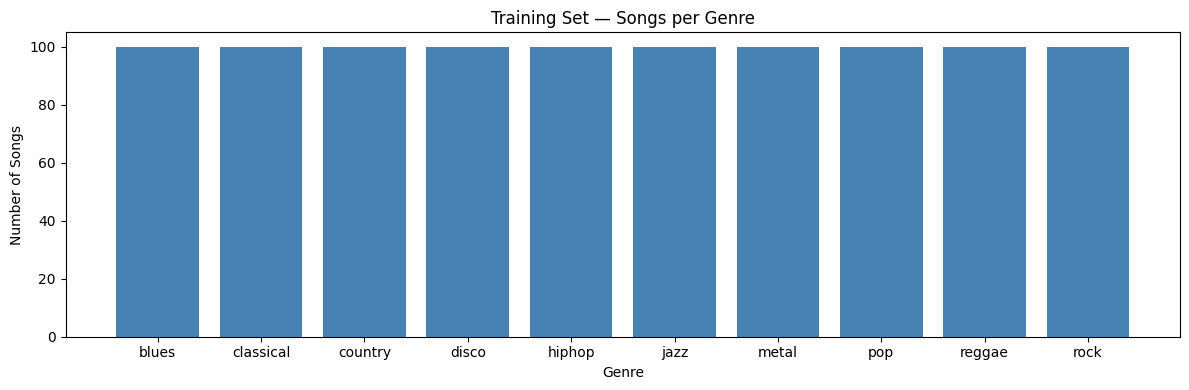

{'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}


In [5]:
# Genre distribution
genre_counts = {}
for g in GENRES:
    gpath = os.path.join(GENRE_ROOT, g)
    genre_counts[g] = len([s for s in os.listdir(gpath)
                           if os.path.isdir(os.path.join(gpath, s))])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(genre_counts.keys(), genre_counts.values(), color='steelblue')
ax.set_title("Training Set — Songs per Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Songs")
plt.tight_layout()
plt.savefig("eda_genre_distribution.png")
plt.show()

wandb.log({"eda/genre_distribution": wandb.Image("eda_genre_distribution.png")})
print(genre_counts)

### 4.2 Audio Waveform & Mel Spectrogram Visualization
Visualizing a sample from each of 3 genres to understand the
audio characteristics that distinguish them.

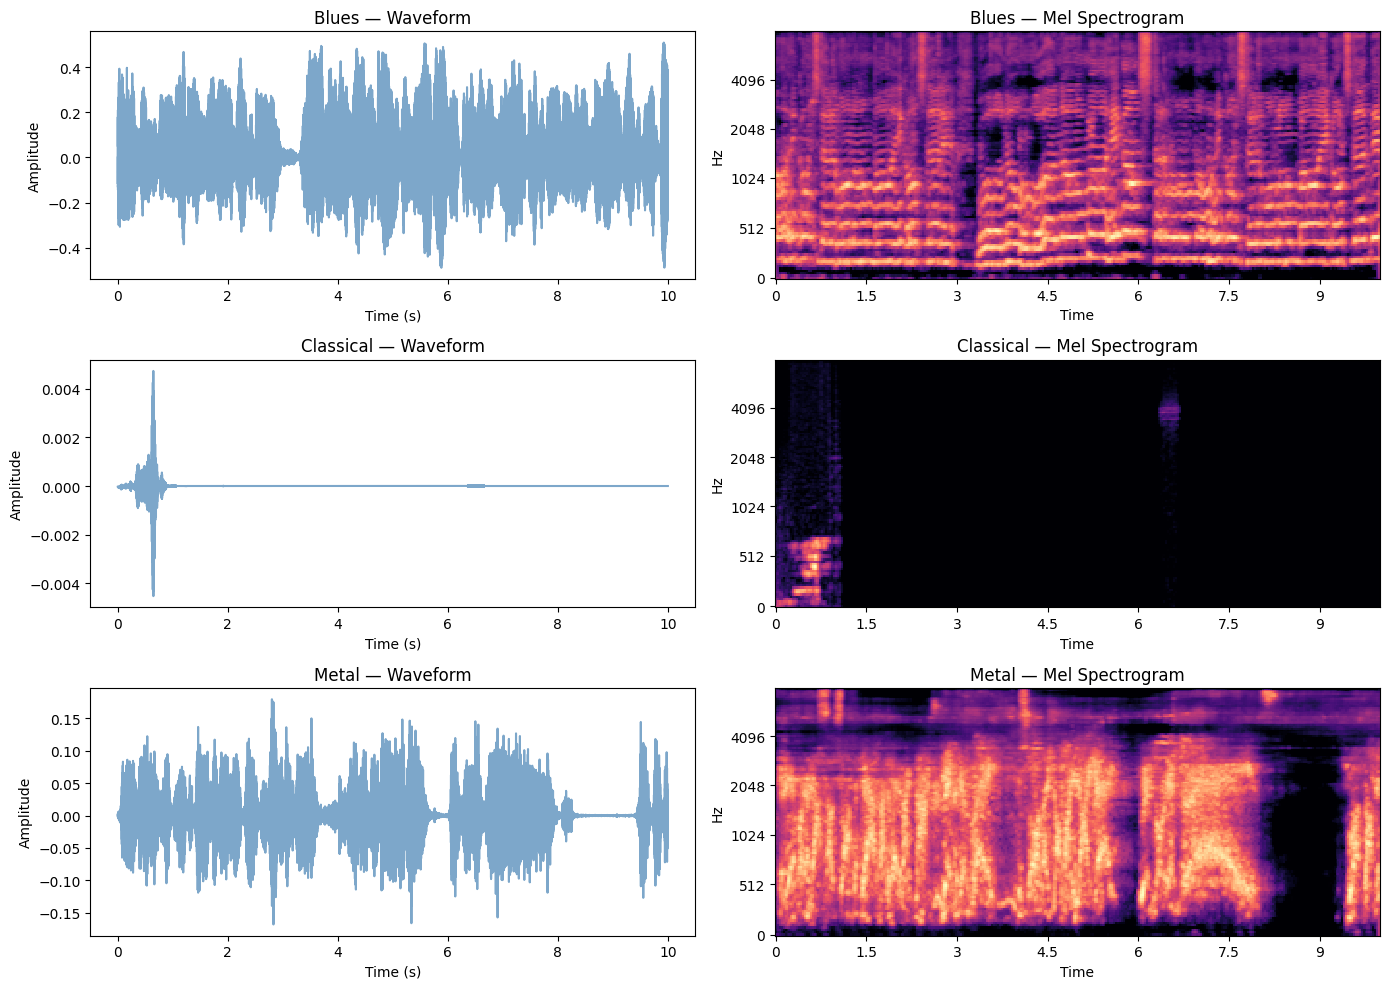

In [6]:
def load_audio_fixed(path, sr=SR, duration=10):
    """Load audio, resample, pad/trim to fixed duration."""
    try:
        y, file_sr = sf.read(path)
        if len(y.shape) > 1:
            y = y.mean(axis=1)
        y = y.astype(np.float32)
        if file_sr != sr:
            y = librosa.resample(y=y, orig_sr=file_sr, target_sr=sr)
    except:
        y, _ = librosa.load(path, sr=sr, mono=True)
    samples = sr * duration
    if len(y) < samples:
        y = np.pad(y, (0, samples - len(y)))
    return y[:samples].astype(np.float32)

# Plot waveform + mel spectrogram for 3 sample genres
sample_genres = ["blues", "classical", "metal"]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, g in enumerate(sample_genres):
    gpath    = os.path.join(GENRE_ROOT, g)
    song_dir = os.path.join(gpath, os.listdir(gpath)[0])
    stem_path= os.path.join(song_dir, "vocals.wav")
    y        = load_audio_fixed(stem_path)

    # Waveform
    axes[i, 0].plot(np.linspace(0, 10, len(y)), y, alpha=0.7, color='steelblue')
    axes[i, 0].set_title(f"{g.capitalize()} — Waveform")
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")

    # Mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SR, x_axis='time',
                             y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f"{g.capitalize()} — Mel Spectrogram")

plt.tight_layout()
plt.savefig("eda_waveforms_spectrograms.png")
plt.show()
wandb.log({"eda/waveforms_spectrograms": wandb.Image("eda_waveforms_spectrograms.png")})

### 4.3 Noise Sample Analysis
The ESC-50 dataset provides 2000 environmental noise clips across 50 classes.
These are mixed into training and test mashups at varying SNR levels.

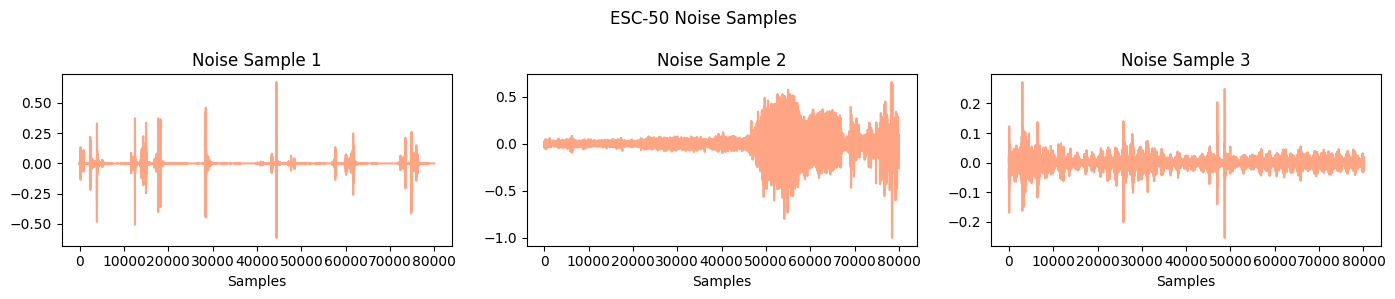

Total noise files available: 2000


In [7]:
noise_files = [os.path.join(NOISE_ROOT, f)
               for f in os.listdir(NOISE_ROOT) if f.endswith(".wav")]

# Plot a few noise waveforms
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i in range(3):
    y, _ = librosa.load(noise_files[i*100], sr=SR)
    axes[i].plot(y, alpha=0.7, color='coral')
    axes[i].set_title(f"Noise Sample {i+1}")
    axes[i].set_xlabel("Samples")

plt.suptitle("ESC-50 Noise Samples")
plt.tight_layout()
plt.savefig("eda_noise_samples.png")
plt.show()
wandb.log({"eda/noise_samples": wandb.Image("eda_noise_samples.png")})
print(f"Total noise files available: {len(noise_files)}")

## 🏗️ 5. Model Definitions
Defining all 3 model architectures exactly as used during training.
Weights will be loaded from saved Kaggle Dataset outputs.

### Model 1 — CNNGenre (From Scratch)
4-block CNN trained purely on log-mel spectrograms.

In [8]:
class CNNGenre(nn.Module):
    """
    4-block CNN for genre classification from log-mel spectrograms.
    Built entirely from scratch — no pretrained weights.
    Input : (B, 1, time_frames, n_mels)
    Output: (B, num_classes)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256),
            nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

### Model 2 — ResNet18 (Pretrained)
ImageNet pretrained ResNet18 with custom classification head,
fine-tuned on mel spectrograms treated as 3-channel images.

In [9]:
def build_resnet():
    """
    ResNet18 pretrained on ImageNet, final FC replaced for 10-genre classification.
    Input : (B, 3, 224, 224) mel spectrogram as RGB image
    Output: (B, num_classes)
    """
    model    = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(512, 10)
    )
    return model

### Model 3 — AST (Audio Spectrogram Transformer)
`MIT/ast-finetuned-audioset-10-10-0.4593` fine-tuned for 10-genre classification.
Pure transformer architecture.

In [10]:
def build_ast():
    """
    AST fine-tuned on AudioSet, classification head replaced for 10 genres.
    Input : AST feature extractor output (log-mel fbank features)
    Output: (B, num_classes)
    """
    model = ASTForAudioClassification.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593",
        num_labels=10,
        ignore_mismatched_sizes=True
    )
    return model

## 📦 6. Load Model Weights
Loading saved `.pth` weights from Kaggle Dataset inputs into each model.

In [11]:
# CNN from scratch
cnn_model = CNNGenre(num_classes=10).to(DEVICE)
cnn_model.load_state_dict(torch.load(CNN_WEIGHTS, map_location=DEVICE))
cnn_model.eval()
print("CNN model loaded")

# ResNet18
resnet_model = build_resnet().to(DEVICE)
resnet_model.load_state_dict(torch.load(RESNET_WEIGHTS, map_location=DEVICE))
resnet_model.eval()
print("ResNet18 model loaded")

# AST
ast_model = build_ast().to(DEVICE)
ast_model.load_state_dict(torch.load(AST_WEIGHTS, map_location=DEVICE))
ast_model.eval()
print("AST model loaded")

# AST Feature Extractor
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)
print("\nAll 3 models ready for inference")

CNN model loaded
ResNet18 model loaded


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

AST model loaded


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]


All 3 models ready for inference


## 🔍 7. Inference Pipelines
Each model has its own audio preprocessing and inference function
matching exactly how it was trained.

In [12]:
# ── CNN inference helpers ─────────────────────────────────────
CNN_SAMPLES = SR * 30
N_MELS, N_FFT, HOP_LENGTH = 128, 1024, 320

def cnn_preprocess(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    if len(y) < CNN_SAMPLES:
        y = np.pad(y, (0, CNN_SAMPLES - len(y)))
    y   = y[:CNN_SAMPLES].astype(np.float32)
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    logmel = librosa.power_to_db(mel).T
    logmel = (logmel - np.mean(logmel)) / (np.std(logmel) + 1e-6)
    return torch.tensor(logmel).unsqueeze(0).unsqueeze(0).float()

def predict_cnn(path):
    x = cnn_preprocess(path).to(DEVICE)
    with torch.no_grad():
        return torch.argmax(cnn_model(x), dim=1).item()

# ── ResNet inference helpers ──────────────────────────────────
RESNET_SAMPLES = SR * 5
IMG_SIZE       = 224
mel_transform  = T.MelSpectrogram(sample_rate=SR, n_fft=1024, hop_length=512, n_mels=128)
db_transform   = T.AmplitudeToDB()
resize         = transforms.Resize((IMG_SIZE, IMG_SIZE))

def resnet_preprocess(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    if len(y) < RESNET_SAMPLES:
        y = np.pad(y, (0, RESNET_SAMPLES - len(y)))
    # Take center crop
    start = max(0, (len(y) - RESNET_SAMPLES) // 2)
    y     = y[start:start + RESNET_SAMPLES].astype(np.float32)
    t     = torch.FloatTensor(y).unsqueeze(0)
    mel   = mel_transform(t)
    mel   = db_transform(mel)
    mel   = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    mel   = mel.repeat(3, 1, 1)
    mel   = resize(mel)
    return mel.unsqueeze(0)

def predict_resnet(path):
    x = resnet_preprocess(path).to(DEVICE)
    with torch.no_grad():
        return torch.argmax(resnet_model(x), dim=1).item()

# ── AST inference helpers ─────────────────────────────────────
AST_SAMPLES = SR * 10

def ast_preprocess(path):
    try:
        y, file_sr = sf.read(path)
        if len(y.shape) > 1:
            y = y.mean(axis=1)
        y = y.astype(np.float32)
        if file_sr != SR:
            y = librosa.resample(y=y, orig_sr=file_sr, target_sr=SR)
    except:
        y, _ = librosa.load(path, sr=SR, mono=True)
    if len(y) < AST_SAMPLES:
        y = np.pad(y, (0, AST_SAMPLES - len(y)))
    return y[:AST_SAMPLES].astype(np.float32)

def predict_ast(path):
    y      = ast_preprocess(path)
    inputs = feature_extractor(y, sampling_rate=SR, return_tensors="pt")
    x      = inputs["input_values"].to(DEVICE)
    with torch.no_grad():
        return torch.argmax(ast_model(x).logits, dim=1).item()

print("Inference pipelines ready")

Inference pipelines ready


## 🚀 8. Run Inference — All 3 Models
Running predictions on all 3020 test mashups using each model.
Results logged to W&B for comparison.

In [13]:
test_df = pd.read_csv(TEST_CSV)

cnn_preds    = []
resnet_preds = []
ast_preds    = []

print("Running inference on all 3 models...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    path = os.path.join(DATA_ROOT, row["filename"])

    try:
        cnn_preds.append(idx_to_genre[predict_cnn(path)])
    except:
        cnn_preds.append("rock")

    try:
        resnet_preds.append(idx_to_genre[predict_resnet(path)])
    except:
        resnet_preds.append("rock")

    try:
        ast_preds.append(idx_to_genre[predict_ast(path)])
    except:
        ast_preds.append("rock")

print("Inference complete")
print(f"CNN    predictions: {len(cnn_preds)}")
print(f"ResNet predictions: {len(resnet_preds)}")
print(f"AST    predictions: {len(ast_preds)}")

Running inference on all 3 models...


100%|██████████| 3020/3020 [13:41<00:00,  3.68it/s]

Inference complete
CNN    predictions: 3020
ResNet predictions: 3020
AST    predictions: 3020


## 📊 9. Compare Model Predictions & Log to W&B
Comparing prediction distributions across all 3 models and logging
a comparison table to Weights & Biases.

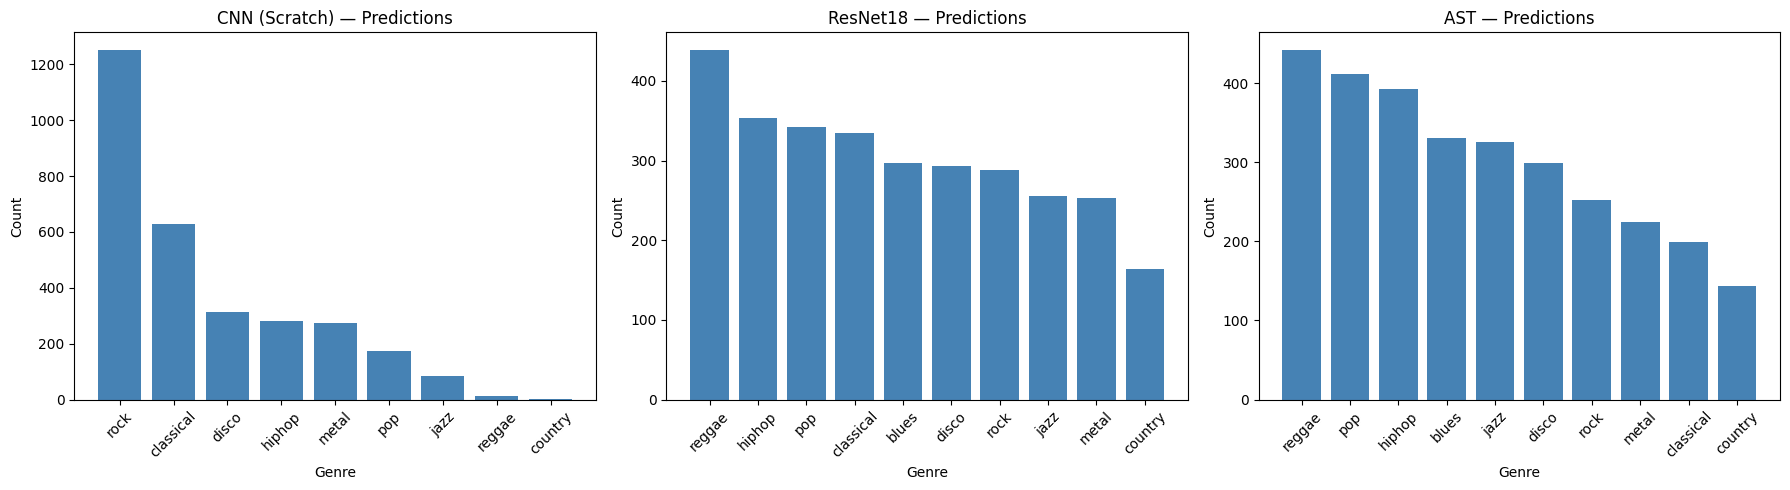

Comparison logged to W&B


In [14]:
# Prediction distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = ["CNN (Scratch)", "ResNet18", "AST"]
all_preds   = [cnn_preds, resnet_preds, ast_preds]

for ax, name, preds in zip(axes, model_names, all_preds):
    counts = pd.Series(preds).value_counts()
    ax.bar(counts.index, counts.values, color='steelblue')
    ax.set_title(f"{name} — Predictions")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()
wandb.log({"comparison/prediction_distributions": wandb.Image("model_comparison.png")})

# W&B comparison table
table = wandb.Table(columns=["id", "CNN", "ResNet18", "AST"])
for i, row in test_df.iterrows():
    table.add_data(row["id"], cnn_preds[i], resnet_preds[i], ast_preds[i])
wandb.log({"comparison/predictions_table": table})

print("Comparison logged to W&B")

## 💾 10. Save Final Submission
Using **RESNET Predictions** as the final submission — our best model at 0.80+ Macro F1.

In [15]:
submission = pd.DataFrame({
    "id"   : test_df["id"],
    "genre": resnet_preds
})
submission.to_csv("submission.csv", index=False)
print("Final submission saved")
print(submission["genre"].value_counts())
submission.head(10)

Final submission saved
genre
reggae       439
hiphop       353
pop          342
classical    335
blues        297
disco        293
rock         288
jazz         256
metal        253
country      164
Name: count, dtype: int64


,id,genre
0,1,pop
1,2,rock
2,3,reggae
3,4,classical
4,5,country
5,6,pop
6,7,rock
7,8,pop
8,9,pop
9,10,disco


## 🤗 11. Push Best Model to HuggingFace Hub
Pushing the resnet18 model to HuggingFace Hub for deployment.
This enables the model to be loaded anywhere without retraining.

In [16]:
from huggingface_hub import HfApi, login

# Login to HuggingFace
from kaggle_secrets import UserSecretsClient
hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)

# Save model locally
os.makedirs("hf_model", exist_ok=True)
torch.save(resnet_model.state_dict(), "hf_model/resnet_genre_model.pth")

# Save a model card
with open("hf_model/README.md", "w") as f:
    f.write("""# Messy Mashup — ResNet18 Genre Classifier
Fine-tuned ResNet18 for music genre classification.
- **Task:** Audio Genre Classification
- **Genres:** blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock
- **Score:** 0.81+ Macro F1 on Kaggle Messy Mashup competition
- **Input:** 3-channel Mel Spectrogram (224x224)
""")

# Push to Hub
api     = HfApi()
repo_id = "24f1000743/messy-mashup-resnet-genre"

api.create_repo(repo_id=repo_id, exist_ok=True, private=True)
api.upload_folder(
    folder_path="hf_model",
    repo_id=repo_id,
    repo_type="model"
)
print(f"Model pushed to HuggingFace: https://huggingface.co/{repo_id}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model pushed to HuggingFace: https://huggingface.co/24f1000743/messy-mashup-resnet-genre


## 12. Finish W&B Run

In [17]:
wandb.log({
    "final/submission_count": len(submission),
    "final/best_model"      : "RESNET18 (0.80+ Macro F1)"
})

wandb.finish()
print("W&B run finished")
print("Pipeline complete!")

W&B run finished
Pipeline complete!
